
First 5 Rows
        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory u

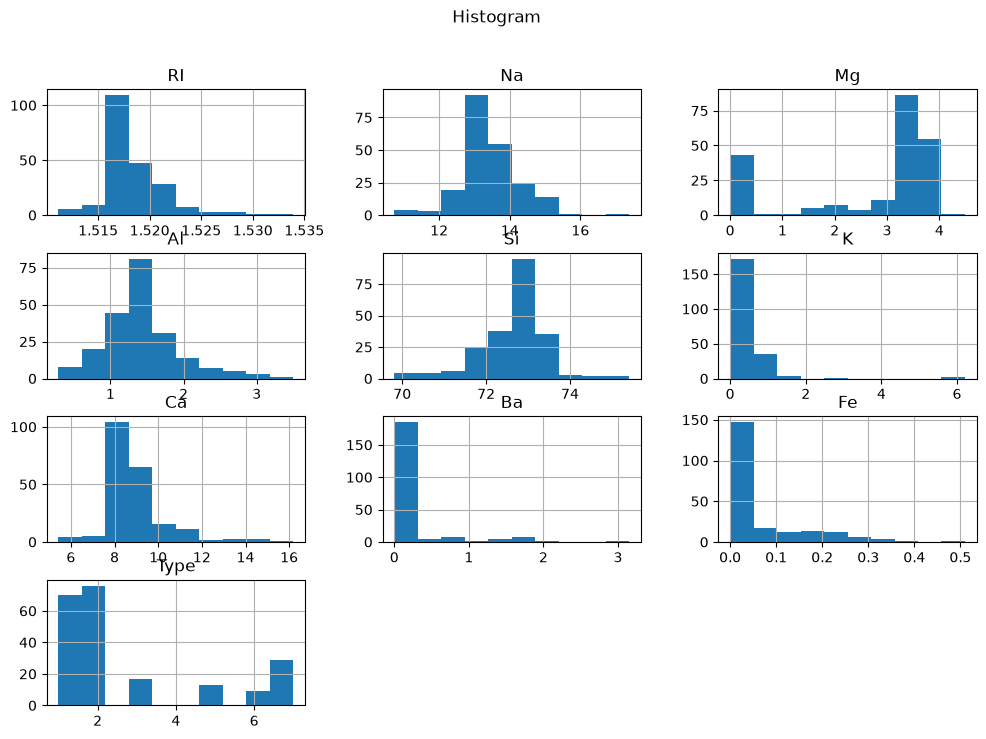

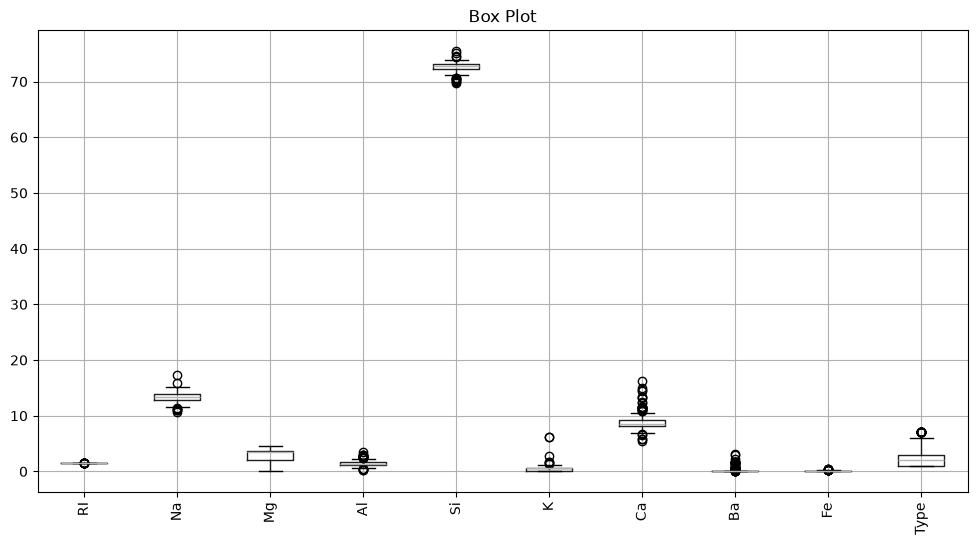

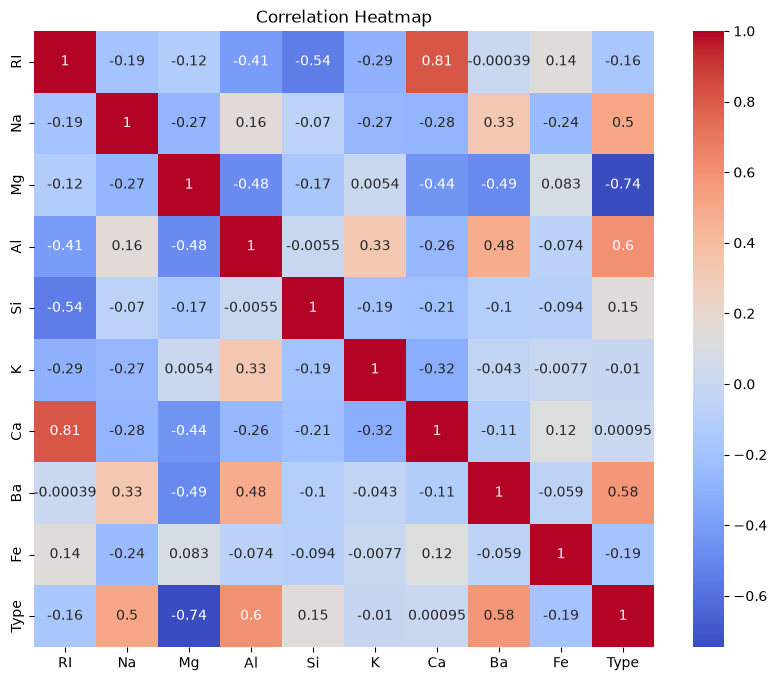

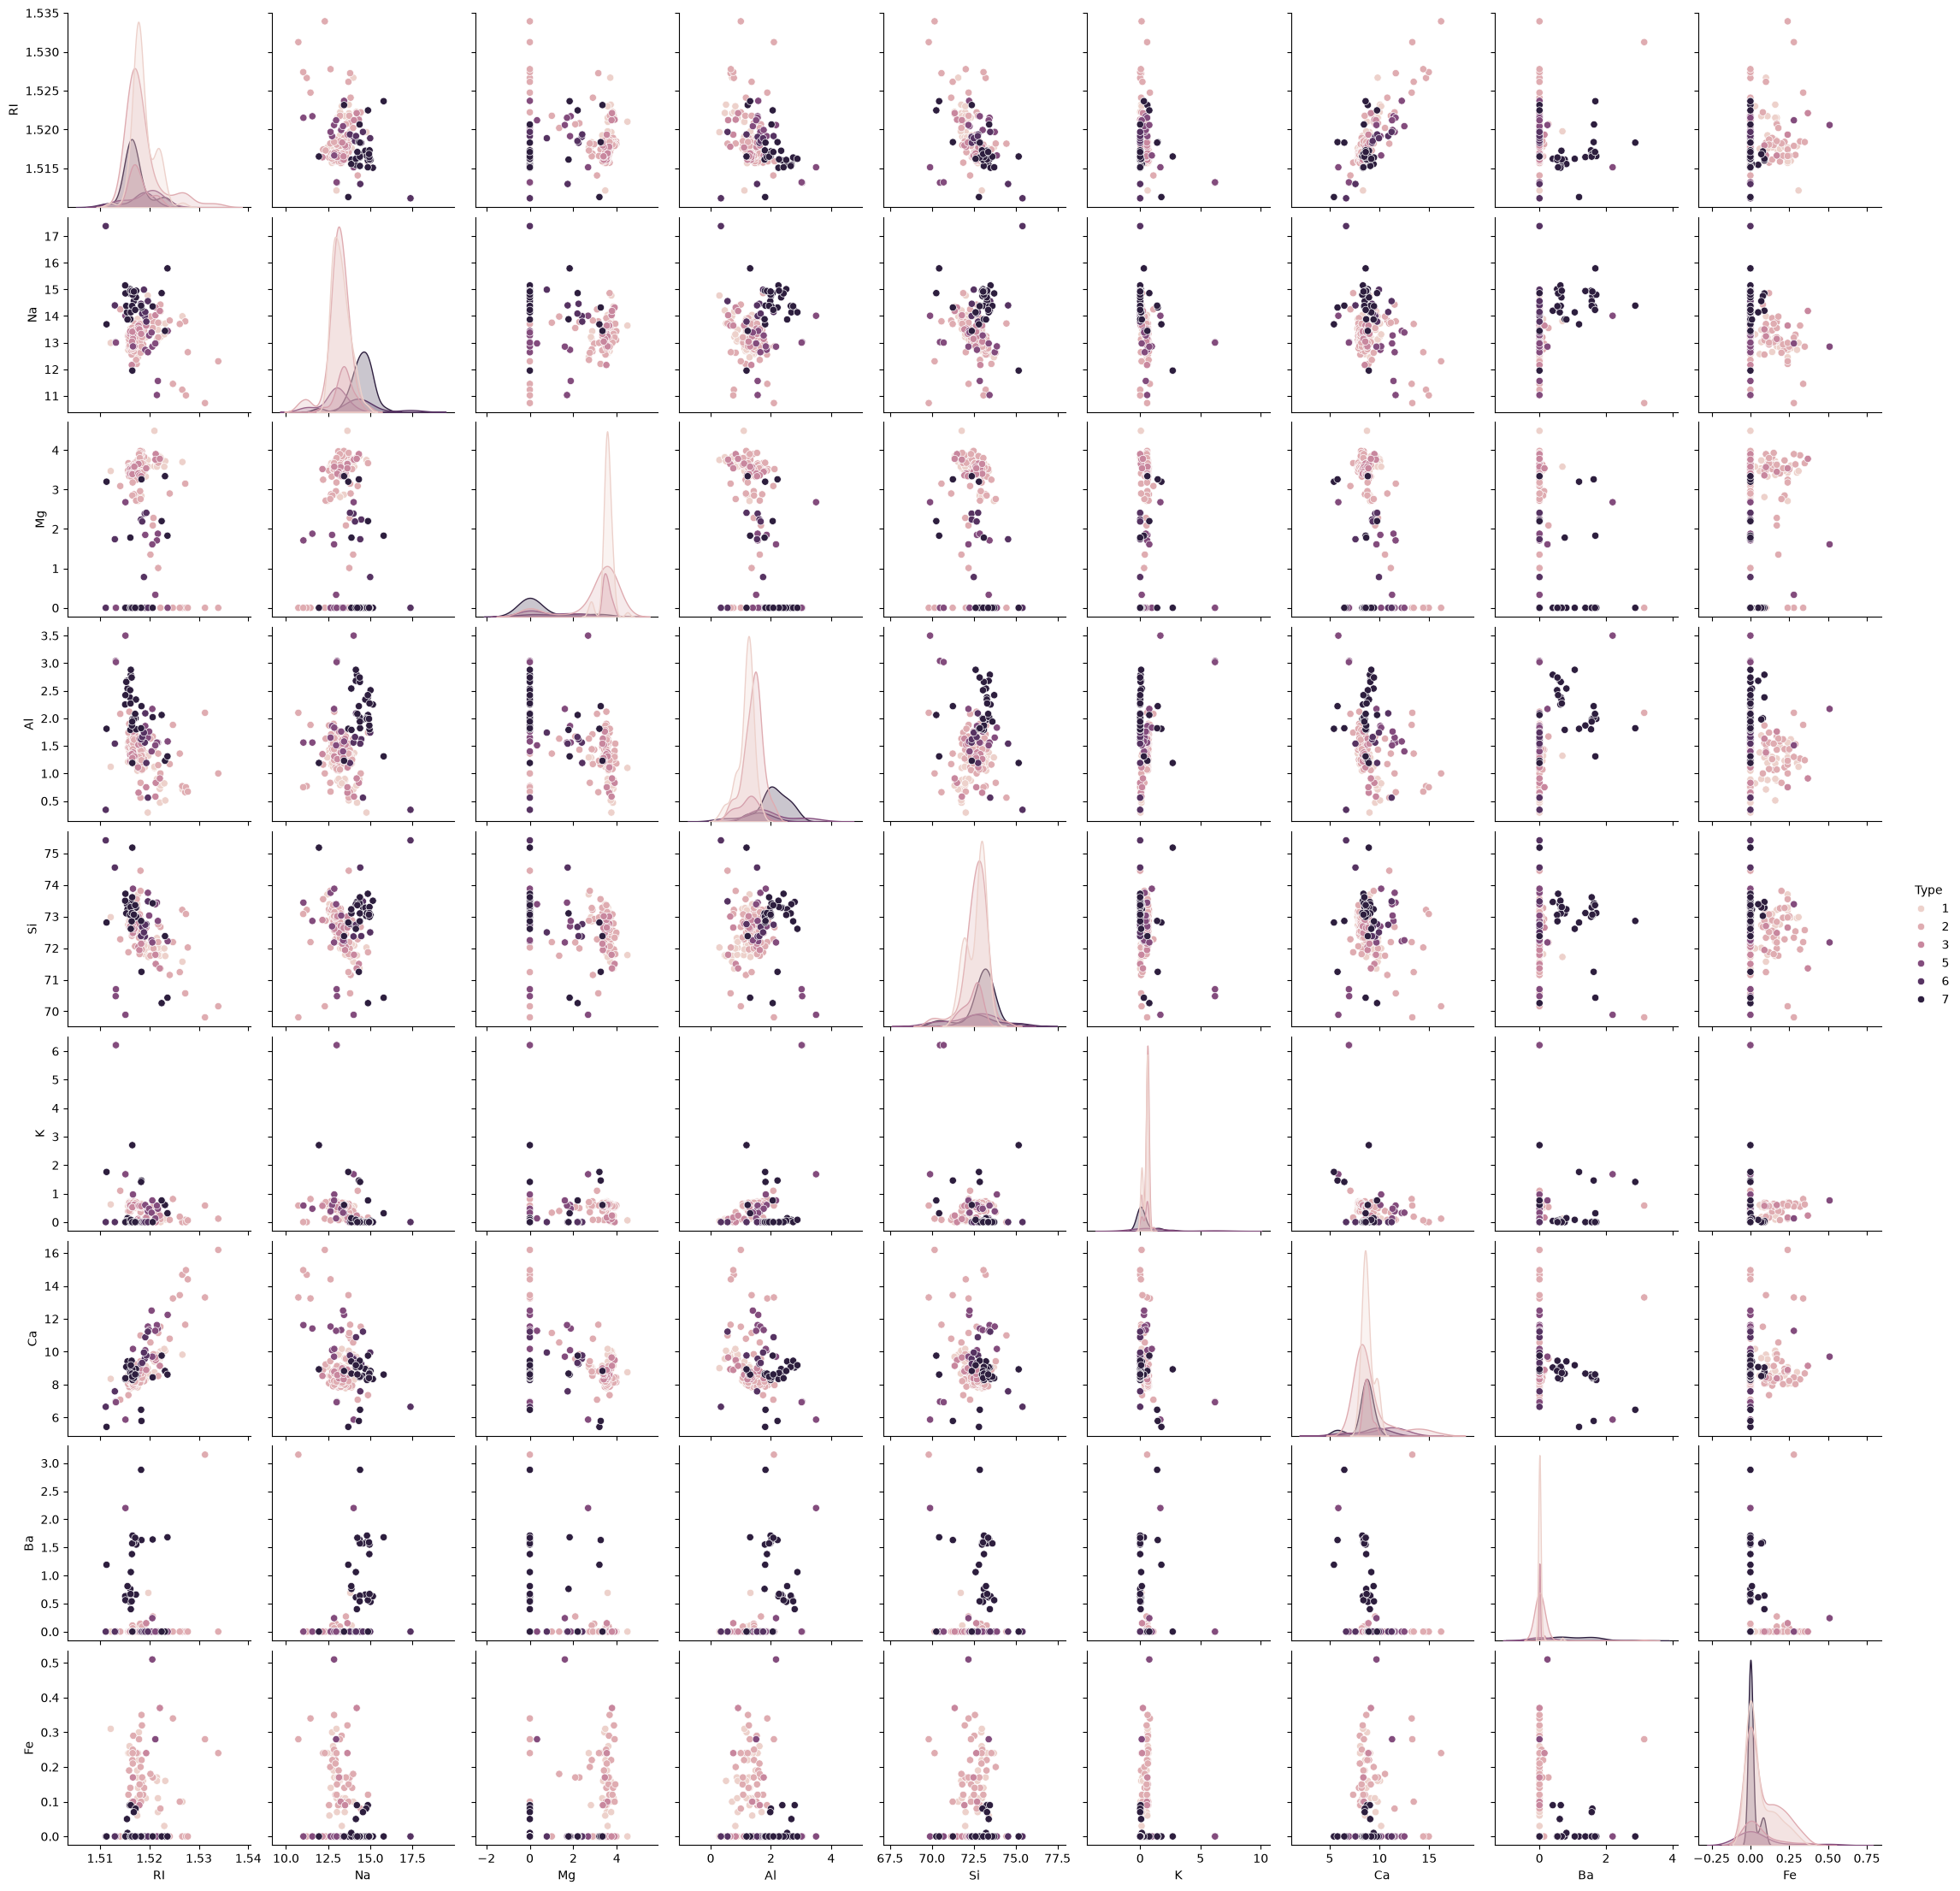


Outlier Detection (IQR Method)
  Column  Outlier Count
0     RI             17
1     Na              7
2     Al             18
3     Si             12
4      K              7
5     Ca             26
6     Ba             38
7     Fe             12
8   Type             29

Class Distribution
Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64

Best Hyperparameters
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best Cross-Validation Score: 0.777

Random Forest
Accuracy : 0.8372093023255814
Precision: 0.8505196354033563
Recall: 0.8372093023255814
F1 Score: 0.8351383328127513

Classification Report
              precision    recall  f1-score   support

           1       0.85      0.79      0.81        14
           2       0.92      0.73      0.81        15
           3       0.75      1.00      0.86         3
           5       0.75      1.00      0.86         3
           6       0.67      1.00      0.80         2
        

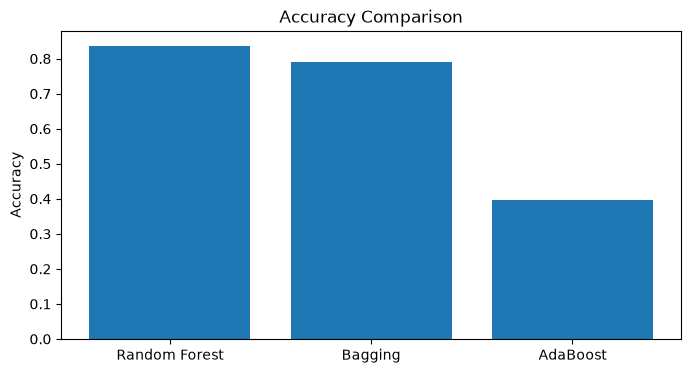

In [1]:
# Random Forest on Glass Dataset
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# Function 1 : Load Dataset

def load_data():
    base_path = pathlib.Path.cwd()
    excel_path = base_path / "glass.xlsx"
    data = pd.read_excel(excel_path, sheet_name="glass")
    return data

# Function 2 : Exploratory Data Analysis

def perform_eda(data):
    print("\nFirst 5 Rows")
    print(data.head())

    print("\nDataset Information")
    print(data.info())

    print("\nStatistical Summary")
    print(data.describe())

    print("\nMissing Values")
    print(data.isnull().sum())

    print("\nDuplicate Rows :", data.duplicated().sum())

    print("\nTarget Class Count")
    print(data.iloc[:, -1].value_counts())

# Function 3 : Data Visualization

def visualize_data(data):
    numeric_data = data.select_dtypes(include=["number", "datetime"])
    target_col = data.columns[-1]

    if not numeric_data.empty:
        numeric_data.hist(figsize=(12, 8))
        plt.suptitle("Histogram")
        plt.show()

        plt.figure(figsize=(12, 6))
        numeric_data.boxplot(rot=90)
        plt.title("Box Plot")
        plt.show()

        plt.figure(figsize=(10, 8))
        sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")
        plt.title("Correlation Heatmap")
        plt.show()
    else:
        print("No numerical or datetime columns available for histogram, boxplot, or correlation heatmap.")

    if len(numeric_data.columns) >= 1:
        plot_data = numeric_data.copy()
        if target_col not in plot_data.columns:
            plot_data[target_col] = data[target_col]

        if plot_data.shape[1] >= 2:
            sns.pairplot(plot_data, hue=target_col)
            plt.show()
        else:
            print("Not enough numeric columns available for a pairplot.")
    else:
        print("Skipping pairplot because there are no numeric features.")

# Function 4 : Outlier Detection

def detect_outliers(data):
    numeric_data = data.select_dtypes(include=["number"])
    outlier_summary = {}

    for column in numeric_data.columns:
        q1 = numeric_data[column].quantile(0.25)
        q3 = numeric_data[column].quantile(0.75)
        iqr = q3 - q1
        lower_limit = q1 - 1.5 * iqr
        upper_limit = q3 + 1.5 * iqr
        outlier_count = ((numeric_data[column] < lower_limit) | (numeric_data[column] > upper_limit)).sum()
        if outlier_count > 0:
            outlier_summary[column] = int(outlier_count)

    print("\nOutlier Detection (IQR Method)")
    if outlier_summary:
        print(pd.DataFrame({"Column": outlier_summary.keys(), "Outlier Count": outlier_summary.values()}))
    else:
        print("No outliers detected.")

    return outlier_summary

# Function 5 : Data Preprocessing

def preprocess_data(data):
    data = data.copy()

    data.fillna(data.mean(numeric_only=True), inplace=True)

    target = data.columns[-1]
    if data[target].dtype == "object":
        encoder = LabelEncoder()
        data[target] = encoder.fit_transform(data[target])

    X = data.iloc[:, :-1]
    y = data.iloc[:, -1]

    print("\nClass Distribution")
    print(y.value_counts())

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    return X, y

# Function 6 : Train-Test Split

def split_data(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y,
    )
    return X_train, X_test, y_train, y_test

# Function 7 : Model Evaluation

def evaluate_model(model_name, y_test, predictions):
    print("\n===================================")
    print(model_name)
    print("===================================")

    metrics = {
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, predictions, average="weighted", zero_division=0),
        "F1": f1_score(y_test, predictions, average="weighted", zero_division=0),
    }

    print("Accuracy :", metrics["Accuracy"])
    print("Precision:", metrics["Precision"])
    print("Recall:", metrics["Recall"])
    print("F1 Score:", metrics["F1"])

    print("\nClassification Report")
    print(classification_report(y_test, predictions))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, predictions))

    return metrics

# Function 8 : Hyperparameter Tuning for Random Forest

def tune_random_forest(X_train, y_train):
    param_grid = {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 5, 10, 15],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    }

    model = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring="f1_weighted",
        n_jobs=-1,
    )
    grid_search.fit(X_train, y_train)

    print("\nBest Hyperparameters")
    print(grid_search.best_params_)
    print("Best Cross-Validation Score:", round(grid_search.best_score_, 3))

    return grid_search.best_estimator_

# Function 9 : Random Forest

def random_forest_model(X_train, X_test, y_train, y_test):
    tuned_model = tune_random_forest(X_train, y_train)
    tuned_model.fit(X_train, y_train)
    predictions = tuned_model.predict(X_test)
    metrics = evaluate_model("Random Forest", y_test, predictions)
    return metrics

# Function 10 : Bagging

def bagging_model(X_train, X_test, y_train, y_test):
    model = BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=100,
        random_state=42,
    )
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    metrics = evaluate_model("Bagging", y_test, predictions)
    return metrics

# Function 11 : Boosting

def boosting_model(X_train, X_test, y_train, y_test):
    model = AdaBoostClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    metrics = evaluate_model("AdaBoost", y_test, predictions)
    return metrics

# Function 12 : Compare Models

def compare_models(results):
    result = pd.DataFrame(results)

    print("\nModel Comparison")
    print(result)

    plt.figure(figsize=(8, 4))
    plt.bar(result["Model"], result["Accuracy"])
    plt.title("Accuracy Comparison")
    plt.ylabel("Accuracy")
    plt.show()

# Main Function

def main():
    data = load_data()
    perform_eda(data)
    visualize_data(data)
    detect_outliers(data)

    X, y = preprocess_data(data)
    X_train, X_test, y_train, y_test = split_data(X, y)

    rf_metrics = random_forest_model(X_train, X_test, y_train, y_test)
    bag_metrics = bagging_model(X_train, X_test, y_train, y_test)
    boost_metrics = boosting_model(X_train, X_test, y_train, y_test)

    compare_models([
        {"Model": "Random Forest", **rf_metrics},
        {"Model": "Bagging", **bag_metrics},
        {"Model": "AdaBoost", **boost_metrics},
    ])

if __name__ == "__main__":
    main()